# Task 1: Exploring and Visualizing the Iris Dataset

**Internship:** DevelopersHub Corporation — Data Science & Analytics Internship

## Introduction & Problem Statement

The goal of this task is to understand how to read, summarize, and visualize a dataset using Python.
We use the **Iris dataset**, a classic dataset in data science containing measurements of 150 iris
flowers from 3 species (*setosa*, *versicolor*, *virginica*). The aim is to:
- Load and inspect the dataset's structure
- Summarize it statistically
- Visualize relationships, distributions, and outliers using scatter plots, histograms, and box plots


## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Dataset Understanding & Description

Load the Iris dataset using seaborn's built-in loader (no external CSV download needed).

In [2]:
# Load the Iris dataset directly from seaborn
df = sns.load_dataset("iris")
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Shape of the dataset (rows, columns)
print("Dataset shape:", df.shape)


Dataset shape: (150, 5)


In [4]:
# Column names
print("Columns:", list(df.columns))


Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [5]:
# Quick statistical summary
df.describe()


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# Data types and missing value check
df.info()
print("\nMissing values per column:\n", df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Missing values per column:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


**Observations:**
- The dataset has 150 rows and 5 columns: `sepal_length`, `sepal_width`, `petal_length`, `petal_width`, and `species`.
- There are no missing values, so no cleaning is required for this task.
- `species` is categorical with 3 balanced classes (50 samples each).

## 3. Data Cleaning & Preparation

The Iris dataset is already clean (no nulls, no duplicates to fix), but we verify this explicitly below.

In [7]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Check class balance
print("\nSamples per species:\n", df['species'].value_counts())


Number of duplicate rows: 1

Samples per species:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

### 4.1 Scatter Plot — Relationship between variables

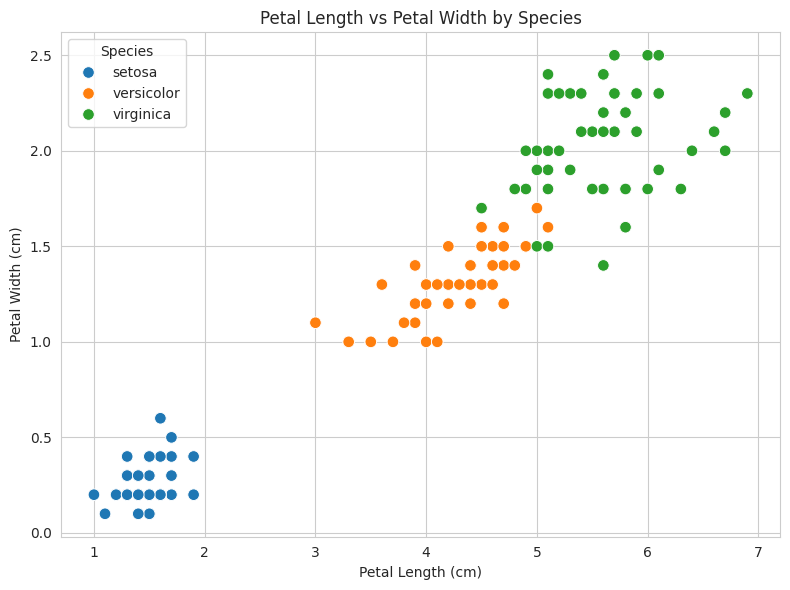

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", s=70)
plt.title("Petal Length vs Petal Width by Species")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()


**Insight:** Petal length and petal width are strongly correlated, and this single pair of features almost perfectly separates the three species — *setosa* is clearly distinct, while *versicolor* and *virginica* show a slight overlap.

### 4.2 Histogram — Distribution of Features

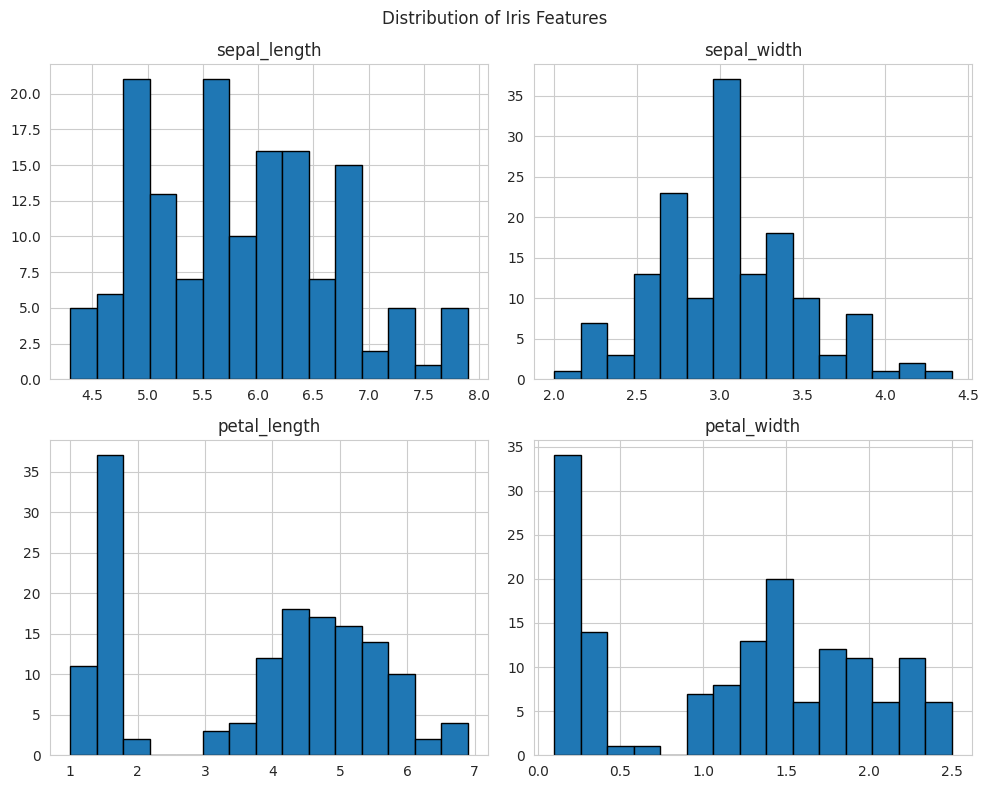

In [9]:
df.drop(columns="species").hist(bins=15, figsize=(10, 8), edgecolor="black")
plt.suptitle("Distribution of Iris Features")
plt.tight_layout()
plt.show()


**Insight:** `sepal_length` and `sepal_width` are roughly normally distributed. `petal_length` and `petal_width` show a clear bimodal pattern — this is a direct result of *setosa* having much smaller petals than the other two species.

### 4.3 Box Plot — Outlier Detection & Spread

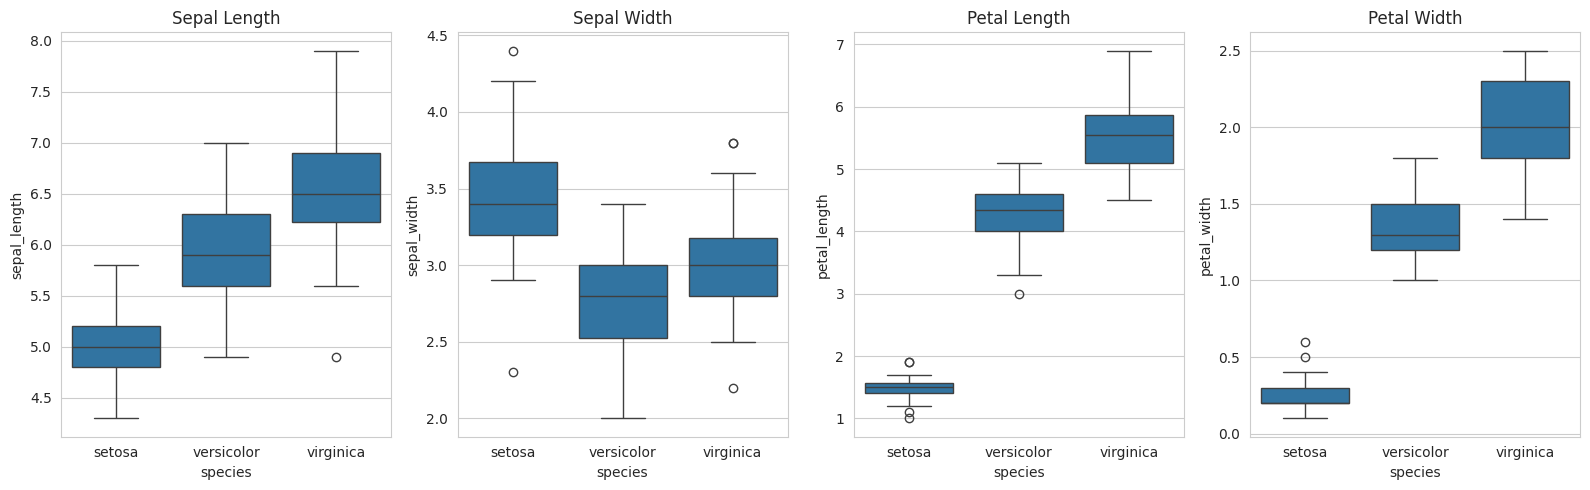

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

for ax, feature in zip(axes, features):
    sns.boxplot(data=df, x="species", y=feature, ax=ax)
    ax.set_title(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()


**Insight:** `sepal_width` shows a few mild outliers (small circles beyond the whiskers), particularly for *virginica*. Petal measurements show very little spread within *setosa*, confirming it's the most distinct species.

### 4.4 Correlation Heatmap (bonus visualization)

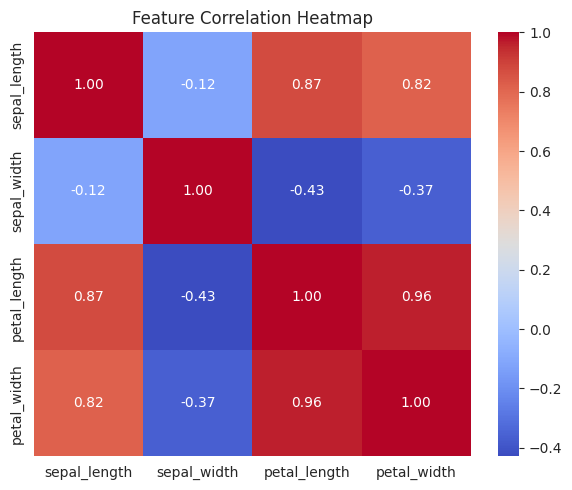

In [11]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.drop(columns="species").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## 5. Model Training and Testing

This task is focused on **data exploration and visualization only** — no predictive model is required per
the task instructions. Model building is covered in Task 2 onward (Credit Risk Prediction, Churn Prediction, etc.).

## 6. Conclusion — Key Insights

- The Iris dataset is small (150 rows), clean, and perfectly balanced across 3 species.
- **Petal length and petal width are the most discriminative features** — they alone can almost perfectly
  separate the three species, which is why they're commonly used in classification tutorials.
- **Sepal measurements overlap more** across species, making them less useful for distinguishing classes on their own.
- *Setosa* is consistently the most distinct/separable species across every visualization; *versicolor* and
  *virginica* show some overlap, especially in sepal width and petal length.
- A few mild outliers exist in `sepal_width`, but nothing severe enough to require removal for this exploratory task.

**Skills demonstrated:** data loading & inspection with pandas, statistical summarization, and visualization
with matplotlib/seaborn (scatter plot, histogram, box plot, heatmap).